In [1]:
import numpy as np
import pandas as pd
import requests

In [ ]:
URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params = {
    "latitude": 28.61,
    "longitude": 77.21,
    "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone",
    "timezone": "auto"
}

print("Fetching air quality data from API...")
response = requests.get(URL, params=params)
data = response.json()

df = pd.DataFrame(data["hourly"])
df["time"] = pd.to_datetime(df["time"])

df.to_csv("data_raw_air_quality.csv", index=False)
df.shape

In [2]:
df= pd.read_csv("data_raw_air_quality.csv")
df.head()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone
0,2026-02-14 00:00:00,99.9,90.8,2692.0,57.2,30.0
1,2026-02-14 01:00:00,94.1,84.5,2670.0,44.3,40.0
2,2026-02-14 02:00:00,88.9,80.1,2510.0,34.4,47.0
3,2026-02-14 03:00:00,88.2,80.1,2109.0,30.0,48.0
4,2026-02-14 04:00:00,90.3,83.4,1571.0,28.6,47.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time              120 non-null    object 
 1   pm10              114 non-null    float64
 2   pm2_5             114 non-null    float64
 3   carbon_monoxide   114 non-null    float64
 4   nitrogen_dioxide  114 non-null    float64
 5   ozone             114 non-null    float64
dtypes: float64(5), object(1)
memory usage: 5.8+ KB


In [4]:
df.isna().sum().sort_values(ascending=False)

pm10                6
pm2_5               6
nitrogen_dioxide    6
carbon_monoxide     6
ozone               6
time                0
dtype: int64

In [5]:
df.describe()

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone
count,114.000000,114.000000,114.000000,114.000000,114.000000
mean,89.539474,78.330702,1149.660526,38.022807,91.692982
std,33.930078,30.564344,596.007547,22.150843,63.454831
min,33.100000,26.100000,348.000000,5.700000,19.000000
25%,59.300000,52.075000,582.000000,18.050000,37.250000
50%,94.750000,81.500000,1107.500000,37.400000,64.500000
75%,111.450000,97.825000,1542.500000,52.875000,154.250000
max,158.800000,151.300000,2692.000000,97.800000,221.000000


In [6]:
df["time"].head()

0    2026-02-14 00:00:00
1    2026-02-14 01:00:00
2    2026-02-14 02:00:00
3    2026-02-14 03:00:00
4    2026-02-14 04:00:00
Name: time, dtype: object

In [7]:
df["time"]= pd.to_datetime(df["time"])
df= df.sort_values("time")   # Sort by time because its important in time data

In [8]:
df= df.ffill()

Doing little bit EDA and Feature Engineering

In [9]:
df["bad_air"]= (df["pm2_5"] >= 60).astype(int)  # Creating classification problem for LogReg

df.head()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone,bad_air
0,2026-02-14 00:00:00,99.9,90.8,2692.0,57.2,30.0,1
1,2026-02-14 01:00:00,94.1,84.5,2670.0,44.3,40.0,1
2,2026-02-14 02:00:00,88.9,80.1,2510.0,34.4,47.0,1
3,2026-02-14 03:00:00,88.2,80.1,2109.0,30.0,48.0,1
4,2026-02-14 04:00:00,90.3,83.4,1571.0,28.6,47.0,1


In [10]:
df["target_next_hour"]= df["bad_air"].shift(-1)  # this predict next hour using current hour

df= df.dropna()

df.head()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone,bad_air,target_next_hour
0,2026-02-14 00:00:00,99.9,90.8,2692.0,57.2,30.0,1,1.0
1,2026-02-14 01:00:00,94.1,84.5,2670.0,44.3,40.0,1,1.0
2,2026-02-14 02:00:00,88.9,80.1,2510.0,34.4,47.0,1,1.0
3,2026-02-14 03:00:00,88.2,80.1,2109.0,30.0,48.0,1,1.0
4,2026-02-14 04:00:00,90.3,83.4,1571.0,28.6,47.0,1,1.0


In [11]:
df["target_next_hour"].value_counts(normalize=True)  # For checking the distribution

target_next_hour
1.0    0.655462
0.0    0.344538
Name: proportion, dtype: float64

## Predicting next hour change

In [12]:
feature= ["pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "ozone"]

X= df[feature]
y= df["target_next_hour"]

In [13]:
# we dont suffel for time data
# we train on past
# and test on future

split= int(len(df)* 0.8)  # index for 80% of rows (used for an 80/20 train–test split)

X_train= X.iloc[:split]
X_test= X.iloc[split:]
y_train= y.iloc[:split]
y_test= y.iloc[split:]

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe= Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("model", LogisticRegression())
    ]
)

In [15]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wor

In [16]:
from sklearn.metrics import roc_auc_score, classification_report

proba= pipe.predict_proba(X_test)[:,1]
preds= (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, preds))

ROC-AUC: 1.0
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96        11
         1.0       1.00      0.92      0.96        13

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



What the Model is learning:... if air is bad now -> it will probably be bad in next hour and vise-versa...

This is basically **Temporal autocorelation**

## Step 2: 
Well Predicting next hour was easy... So, Now we will try to answer another but important question:

Will air quality **WORSEN** next hour?

In [17]:
df["pm2_5_next"] = df["pm2_5"].shift(-1)

df["target_worsening"] = (df["pm2_5_next"] > df["pm2_5"]).astype(int)

df = df.dropna()

In [18]:
df["target_worsening"].value_counts(normalize= True)

target_worsening
1    0.508475
0    0.491525
Name: proportion, dtype: float64

In [19]:
feature= ["pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "ozone"]

X= df[feature]
y= df["target_worsening"]

In [20]:
split= int(len(df)* 0.8)

X_train= X.iloc[:split]
X_test= X.iloc[split:]
y_train= y.iloc[:split]
y_test= y.iloc[split:]

In [21]:
pipe= Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("model", LogisticRegression())
    ]
)

In [22]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wor

In [23]:
proba= pipe.predict_proba(X_test)[:,1]
preds= (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, preds))

ROC-AUC: 0.7132867132867133
              precision    recall  f1-score   support

           0       0.57      0.62      0.59        13
           1       0.50      0.45      0.48        11

    accuracy                           0.54        24
   macro avg       0.54      0.53      0.53        24
weighted avg       0.54      0.54      0.54        24



Accuracy droped?... Yes. 

Is it concerning?... No. Why?... because its a time-series data... and in time-series, the goal is not just to be correct... but to be correct at the right time... 

ROC-AOC is around 71%... so if we randomly pick one 'worsening' hour and one 'non-woresning' the model actually rank the 'worsening' hour higher 71% of the time... 

## Teaching trends

In [24]:
# Lag feature to help model predict future values

df["pm2_5_lag1"] = df["pm2_5"].shift(1)
df["pm2_5_lag2"] = df["pm2_5"].shift(2)

df["pm10_lag1"] = df["pm10"].shift(1)
df["pm10_lag2"] = df["pm10"].shift(2)

df["co_lag1"] = df["carbon_monoxide"].shift(1)
df["co_lag2"] = df["carbon_monoxide"].shift(2)

df["no2_lag1"] = df["nitrogen_dioxide"].shift(1)
df["no2_lag2"] = df["nitrogen_dioxide"].shift(2)

df["o3_lag1"] = df["ozone"].shift(1)
df["o3_lag2"] = df["ozone"].shift(2)

In [25]:
# Trends

df["pm2_5_change_1h"] = df["pm2_5"] - df["pm2_5_lag1"]
df["pm2_5_change_2h"] = df["pm2_5"] - df["pm2_5_lag2"]

df["pm10_change_1h"] = df["pm10"] - df["pm10_lag1"]
df["pm10_change_2h"] = df["pm10"] - df["pm10_lag2"]

df["co_change_1h"] = df["carbon_monoxide"] - df["co_lag1"]
df["co_change_2h"] = df["carbon_monoxide"] - df["co_lag2"]

df["no2_change_1h"] = df["nitrogen_dioxide"] - df["no2_lag1"]
df["no2_change_2h"] = df["nitrogen_dioxide"] - df["no2_lag2"]

df["o3_change_1h"] = df["ozone"] - df["o3_lag1"]
df["o3_change_2h"] = df["ozone"] - df["o3_lag2"]

df = df.dropna()

In [26]:
features = [
    "pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "ozone",
    "pm2_5_lag1", "pm2_5_lag2", "pm10_lag1", "pm10_lag2", "co_lag1", "co_lag2", "no2_lag1", "no2_lag2", "o3_lag1", "o3_lag2",
    "pm2_5_change_1h", "pm2_5_change_2h", "pm10_change_1h", "pm10_change_2h", "co_change_1h", "co_change_2h",
    "no2_change_1h", "no2_change_2h", "o3_change_1h", "o3_change_2h"
]

In [27]:
X = df[features]
y = df["target_worsening"]

In [28]:
split= int(len(df)* 0.8)

X_train= X.iloc[:split]
X_test= X.iloc[split:]
y_train= y.iloc[:split]
y_test= y.iloc[split:]

In [29]:
pipe= Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("model", LogisticRegression())
    ]
)

In [30]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wor

In [31]:
proba= pipe.predict_proba(X_test)[:,1]
preds= (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, preds))

ROC-AUC: 0.8531468531468531
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.89      0.73      0.80        11

    accuracy                           0.83        24
   macro avg       0.84      0.83      0.83        24
weighted avg       0.84      0.83      0.83        24



ROC-AUC improved from 0.713 to now 0.853... this tells that the `lag` and `trends` helped

and accuracy also improved... even with default 0.5 threshold...

What this model good at now:

- [x] Rank hours by risk of worsening air quality
- [x] Capture momentum and trends
- [x] Generalise unseen future hours 

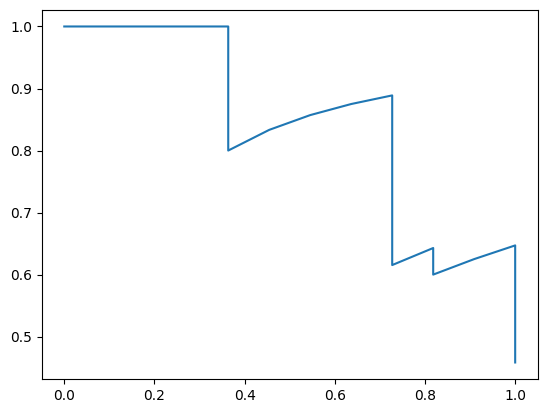

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

y_proba = pipe.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)

In [33]:
thres = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

for t in thres:
    y_pred = (y_proba >= t)
    print(f"Threshold: {t}")
    print("ROC-AOC:",roc_auc_score(y_test, y_proba))
    print("Report:",classification_report(y_test, y_pred))
    print("-"*65)

Threshold: 0.1
ROC-AOC: 0.8531468531468531
Report:               precision    recall  f1-score   support

           0       1.00      0.54      0.70        13
           1       0.65      1.00      0.79        11

    accuracy                           0.75        24
   macro avg       0.82      0.77      0.74        24
weighted avg       0.84      0.75      0.74        24

-----------------------------------------------------------------
Threshold: 0.15
ROC-AOC: 0.8531468531468531
Report:               precision    recall  f1-score   support

           0       0.88      0.54      0.67        13
           1       0.62      0.91      0.74        11

    accuracy                           0.71        24
   macro avg       0.75      0.72      0.70        24
weighted avg       0.76      0.71      0.70        24

-----------------------------------------------------------------
Threshold: 0.2
ROC-AOC: 0.8531468531468531
Report:               precision    recall  f1-score   support

     

In [34]:
coef = pipe.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coef
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
17,pm10_change_1h,0.933567
15,pm2_5_change_1h,0.484916
0,pm10,0.401394
18,pm10_change_2h,0.378756
21,no2_change_1h,0.369931
10,co_lag2,0.241505
8,pm10_lag2,0.165138
7,pm10_lag1,0.095109
12,no2_lag2,0.051362
16,pm2_5_change_2h,0.047281


In [ ]:
pd.Series(y_proba).describe()  # Probability Distribution

count    24.000000
mean      0.412287
std       0.333482
min       0.000019
25%       0.071004
50%       0.409097
75%       0.644138
max       0.941941
dtype: float64

In [36]:
df["pm2_5_roll3"] = df["pm2_5"].rolling(window=3).mean()
df["pm10_roll3"] = df["pm10"].rolling(window=3).mean()
df["co_roll3"] = df["carbon_monoxide"].rolling(window=3).mean()
df["no2_roll3"] = df["nitrogen_dioxide"].rolling(window=3).mean()
df["o3_roll3"] = df["ozone"].rolling(window=3).mean()

df = df.dropna()

In [37]:
features = [
#     current
    'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone',
#     lags
    'pm2_5_lag1', 'pm2_5_lag2', 'pm10_lag1', 'pm10_lag2', 'co_lag1','co_lag2', 
    'no2_lag1', 'no2_lag2', 'o3_lag1', 'o3_lag2',
#     changes
    'pm2_5_change_1h', 'pm2_5_change_2h', 'pm10_change_1h','pm10_change_2h', 'co_change_1h', 'co_change_2h', 
    'no2_change_1h','no2_change_2h', 'o3_change_1h', 'o3_change_2h',
#     rolling
    'pm2_5_roll3','pm10_roll3', 'co_roll3', 'no2_roll3', 'o3_roll3'
]

In [38]:
X= df[features]
y = df["target_worsening"]

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [39]:
pipe = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("model", LogisticRegression())
    ]
)

In [40]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wor

In [41]:
proba= pipe.predict_proba(X_test)[:,1]
preds= (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, preds))

ROC-AUC: 0.923076923076923
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.88      0.70      0.78        10

    accuracy                           0.83        23
   macro avg       0.84      0.81      0.82        23
weighted avg       0.83      0.83      0.82        23



In [42]:
coef = pipe.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coef
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
17,pm10_change_1h,0.743710
15,pm2_5_change_1h,0.669201
10,co_lag2,0.489295
21,no2_change_1h,0.245952
12,no2_lag2,0.195639
27,co_roll3,0.151186
0,pm10,0.116808
16,pm2_5_change_2h,0.113036
8,pm10_lag2,0.076208
18,pm10_change_2h,0.065397


In [45]:
train_probs = pipe.predict_proba(X_train)[:, 1]
print("Train Roc:", roc_auc_score(y_train, train_probs))
print("Test Roc:", roc_auc_score(y_test, proba))

Train Roc: 0.9664723032069971
Test Roc: 0.923076923076923


mm... So why does the ROC increased?

well our target is: `df["target_worsening"] = (df["pm2_5_next"] > df["pm2_5"]).astype(int)` 

and we are feeding:
`pm2_5_change_1h`, `pm2_5_change_2h`, `pm2_5_lag1`, `pm2_5_lag2`, `pm2_5_rpll3`

so the model is pasically learning... If its has been rising recently, it will likely continue rising next hour.

In short its called **Momentum Forecasting**